In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from cmdstanpy import CmdStanModel

In [35]:
model = CmdStanModel(
    stan_file="models/regression_model.stan"
)

In [65]:
data = pd.read_csv("data/generated_data_N20.csv", delimiter=",", header=0)

data_dict = {
    "N": len(data),
    "x": data.X.values,
    "y": data.Y.values,
}

In [66]:
NUM_CHAINS = 4
SAMPLING_ITERS = 5_000

fit = model.sample(
    data=data_dict, 
    chains=NUM_CHAINS, 
    iter_warmup=500, 
    iter_sampling=SAMPLING_ITERS,
)

23:10:48 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

23:10:48 - cmdstanpy - INFO - CmdStan done processing.


In [67]:
summary=fit.summary()
summary.to_csv(f"summary_N{data_dict['N']}.csv",index=False)
summary

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-53.413700,0.015126,1.32322,1.07082,-55.98960,-53.079500,-51.990700,8165.9,9873.76,3775.27,1.000400
alpha,-13.226200,0.017197,1.82721,1.76684,-16.12990,-13.270500,-10.197000,11512.9,10341.10,5322.64,1.000350
beta,8.601340,0.017186,1.77353,1.72625,5.63396,8.632380,11.440900,10815.7,11457.40,5000.30,1.000260
sigma2,44.460100,0.152290,15.76780,12.96440,25.48870,41.323000,73.809500,11428.5,12172.10,5283.62,1.000100
sigma,6.575510,0.010550,1.10581,1.02131,5.04863,6.428290,8.591250,11428.5,12172.10,5283.62,1.000090
y_pp[1],-8.287280,0.048483,6.79922,6.49665,-19.50100,-8.281690,2.832280,19690.6,18902.80,9103.36,0.999996
y_pp[2],-10.674600,0.049376,6.81022,6.58281,-21.84650,-10.688600,0.428328,19058.8,19392.10,8811.26,1.000040
y_pp[3],-1.772200,0.050387,7.03559,6.88735,-13.16980,-1.806170,9.624140,19529.6,19724.50,9028.93,0.999962
y_pp[4],-12.476800,0.050000,6.85739,6.68291,-23.63210,-12.502500,-1.282720,18865.3,18877.10,8721.83,1.000140
y_pp[5],-12.650900,0.050297,6.97787,6.78315,-24.02670,-12.642900,-1.104710,19244.1,19481.20,8896.97,0.999979


In [68]:
print(fit.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



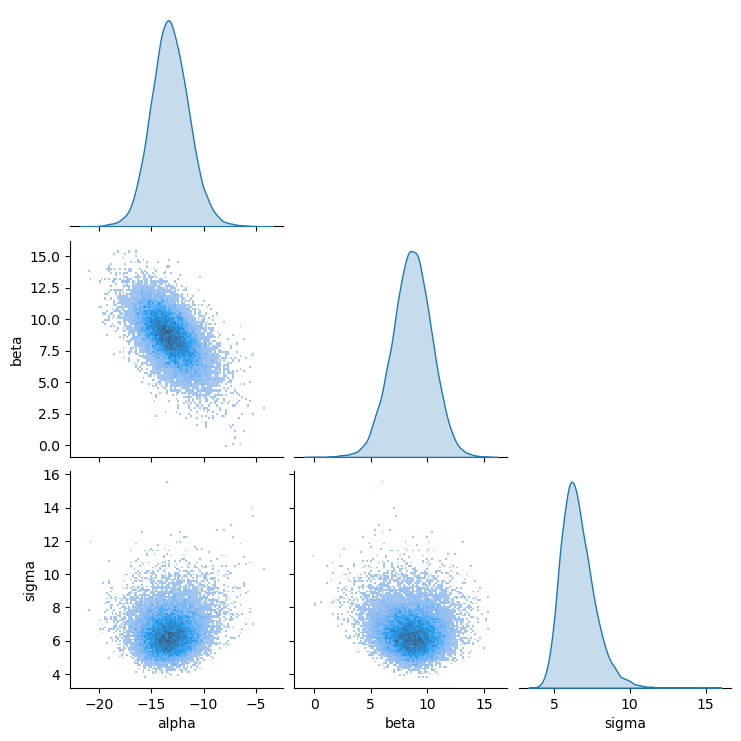

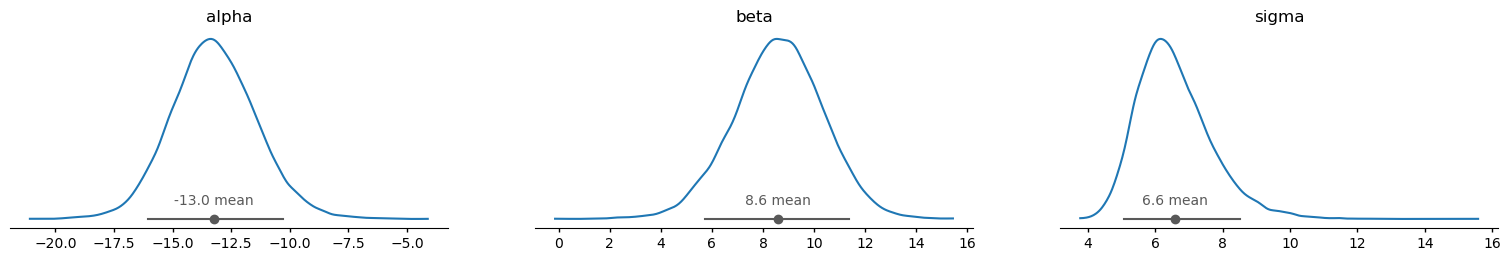

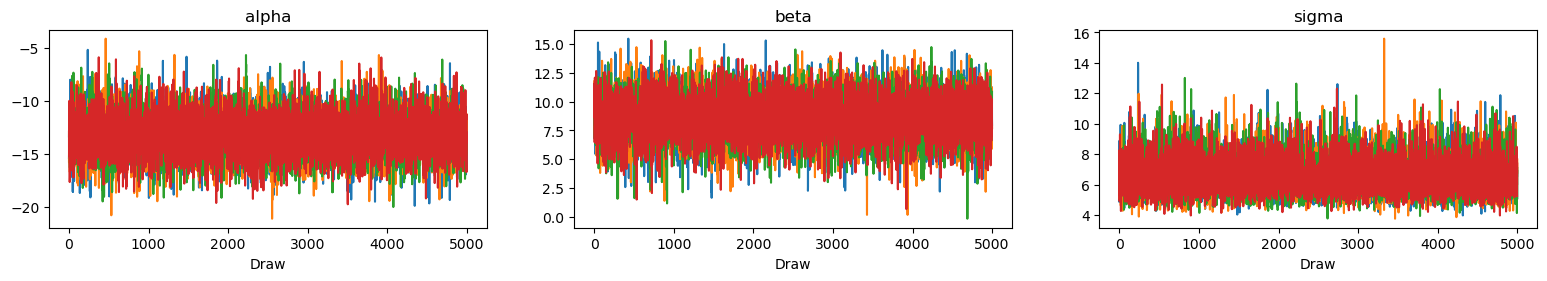

In [69]:
idata = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive="y_pp",
    observed_data={"y": data_dict["y"]}
)
idata
sns.pairplot(
    fit.draws_pd(),vars=["alpha","beta","sigma"],
    kind="hist",diag_kind="kde",corner=True
)
plt.savefig(f"figures/pairplot_N{data_dict['N']}.png")
az.plot_dist(idata,var_names=["alpha","beta","sigma"])
plt.savefig(f"figures/dist_N{data_dict['N']}.png")
az.plot_trace(idata,var_names=["alpha","beta","sigma"])
plt.savefig(f"figures/trace_N{data_dict['N']}.png")


mean:
	alpha = -13.2262
	beta  =  8.6013
	sigma =  6.5755


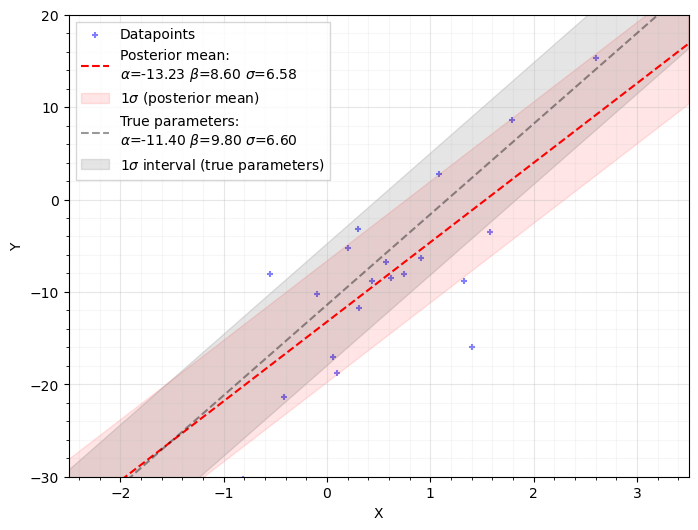

In [70]:
plt.figure(figsize=(8,6))
# N_posterior=len(idata.posterior["alpha"].flatten())
pl_X=np.linspace(-2.5,3.5,2)

alpha_med=np.mean(idata.posterior["alpha"].data.flatten())
beta_med=np.mean(idata.posterior["beta"].data.flatten())
sigma_med=np.mean(idata.posterior["sigma"].data.flatten())
print(f"mean:\n\talpha = {alpha_med: .4f}\n\tbeta  = {beta_med: .4f}\n\tsigma =  {sigma_med:.4f}")

pl_Y_med=alpha_med+pl_X*beta_med
pl_Y_low=pl_Y_med-sigma_med
pl_Y_high=pl_Y_med+sigma_med

plt.scatter(
    data_dict["x"], data_dict["y"],
    marker="+", c="b", s=20, alpha=0.5,
    label="Datapoints"
)

plt.plot(
    pl_X,
    pl_Y_med,
    "r--",
    label=f"Posterior mean:\n$\\alpha$={alpha_med:.2f} $\\beta$={beta_med:.2f} $\\sigma$={sigma_med:.2f}"
)
plt.fill_between(
    pl_X,
    pl_Y_low,
    pl_Y_high,
    color="r",
    alpha=0.1,
    label="1$\\sigma$ (posterior mean)"
)

import json
with open("true_model_params.json") as f:
    true_params=json.load(f)

plt.plot(
    pl_X,
    true_params["alpha_0"]+pl_X*true_params["beta_0"],
    "k--",
    alpha=0.4,
    label=f"True parameters:\n$\\alpha$={true_params['alpha_0']:.2f} $\\beta$={true_params['beta_0']:.2f} $\\sigma$={true_params['sigma_0']:.2f}"
)
plt.fill_between(
    pl_X,
    true_params["alpha_0"]+pl_X*true_params["beta_0"]-true_params["sigma_0"],
    true_params["alpha_0"]+pl_X*true_params["beta_0"]+true_params["sigma_0"],
    color="k",
    alpha=0.1,
    label="1$\\sigma$ interval (true parameters)"
)

plt.minorticks_on()
plt.grid(which="major", alpha=0.3)
plt.grid(which="minor", alpha=0.1)
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(-2.5,3.5)
plt.ylim(-30,20)
plt.legend(fancybox=False)
plt.savefig(f"figures/meanfit_N{data_dict['N']}.png")
